# Chapter 4.3 k-means 클러스터링 — 실습 노트북

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SuminHan/book-ml/blob/main/notebooks/ml1/chapter04_3_kmeans.ipynb)

책 본문: [4.3 k-means 클러스터링](https://smhanlab.com/book-ml/kor/ml1/chapter04/3.html)

이 노트북은 책 4.3절의 k-means 코드를 그대로 실행하고, (1) 3-블롭 장난감 데이터에서 **수렴 과정을 단계별로 찍은 그림**(할당 결과 + 중심점 이동 화살표)을 보여주고, (2) \(k=1\sim6\)의 SSE로 **엘보우 방법**을 확인하고, (3) 무작위 초기화 60회 중 **나쁜 지역최적해에 빠지는 실패 사례**를 실제로 만들어 보고, (4) **k-means++ 초기화**의 차이를 비교합니다. numpy/matplotlib만 씁니다. (본문에 적힌 특정 숫자(예: 실패 1회, SSE 1845.3)는 재현을 목표로 하지 않으며, 같은 "현상"이 실제로 일어나는지만 확인합니다.)

## 1. 장난감 데이터: 3개의 원형 덩어리 (각 50점, 총 150점)

데이터: 150점 x 2차원 (3개 덩어리, 각 50점)


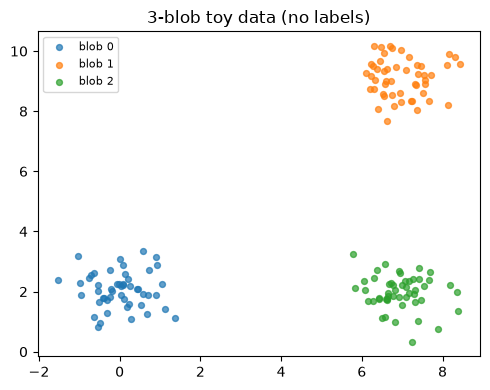

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RNG = np.random.RandomState(0)

blobs = [
    RNG.normal((0, 2), 0.6, (50, 2)),
    RNG.normal((7, 9), 0.6, (50, 2)),
    RNG.normal((7, 2), 0.6, (50, 2)),
]
X = np.vstack(blobs)
n, d = X.shape
print(f"데이터: {n}점 x {d}차원 (3개 덩어리, 각 50점)")

plt.figure(figsize=(5, 4))
for i, b in enumerate(blobs):
    plt.scatter(b[:, 0], b[:, 1], s=18, alpha=0.7, label=f"blob {i}")
plt.title("3-blob toy data (no labels)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2. 책 본문의 k-means 함수 (numpy 버전)

In [2]:
def kmeans(X, k, max_iters=100):
    """책 본문의 순차 k-means (중심점 무작위 샘플링 초기화)"""
    centroids = X[RNG.choice(n, size=k, replace=False)]
    for it in range(1, max_iters + 1):
        dist2 = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = dist2.argmin(axis=1)
        new_centroids = np.array(
            [X[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i]
             for i in range(k)])
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids
    return centroids, labels, it

def sse(X, labels, centroids):
    dist2 = np.linalg.norm(X - centroids[labels], axis=1)
    return dist2.sum()

centroids, labels, iters = kmeans(X, k=3)
print(f"수렴: {iters}회차, 최종 SSE = {sse(X, labels, centroids):.1f}")
print("클러스터 크기:", [int((labels == i).sum()) for i in range(3)])

수렴: 7회차, 최종 SSE = 393.3
클러스터 크기: [38, 100, 12]


## 3. 수렴 과정 단계별 시각화

할당 결과(점의 색상 = 할당된 클러스터) + 이전→이후 중심점 이동 화살표를 매 반복마다 찍는다. "중심점이 그룹의 평균으로 재계산된다"는 문장을 눈으로 확인할 수 있다. (본문에서 이 코드의 `plt.savefig("kmeans_result.png")` 부분을 한 장의 그리드로 묶은 것.)

SVG 저장: kor/src/images/ch04_kmeans_convergence.svg


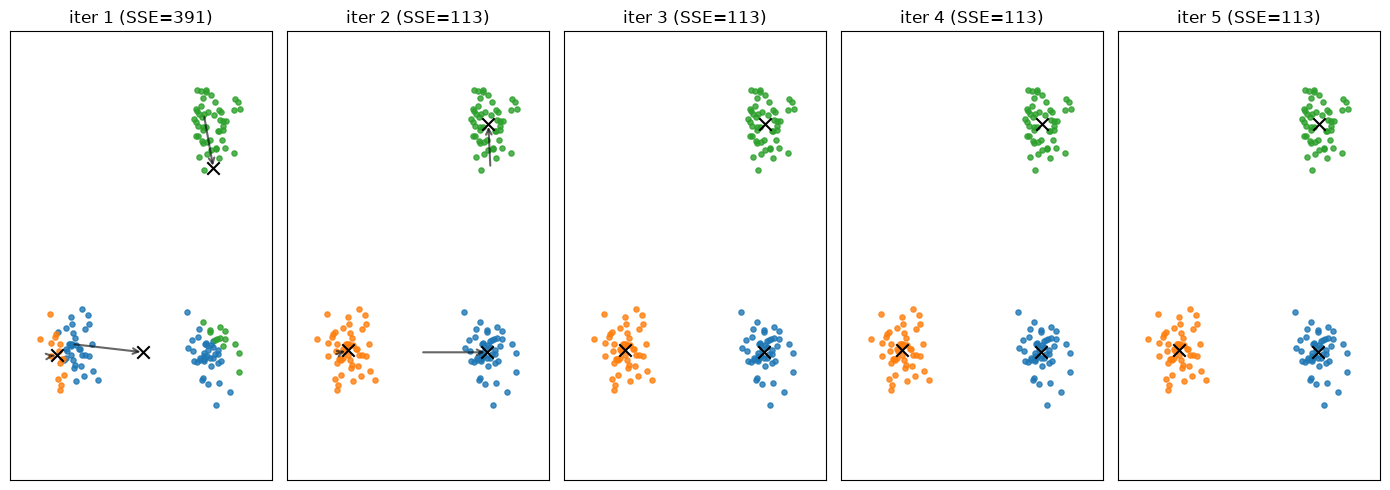

In [3]:
def plot_convergence(X, k, max_iters=12, figsize=(14, 5)):
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    centroids = X[RNG.choice(n, size=k, replace=False)]
    n_panels = min(max_iters, 5)
    fig, axes = plt.subplots(1, n_panels, figsize=figsize)
    for it in range(1, n_panels + 1):
        ax = axes[it - 1]
        ax.set_xticks([]); ax.set_yticks([])
        ax = axes[it - 1]
        dist2 = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = dist2.argmin(axis=1)
        prev = centroids.copy()
        new_centroids = np.array(
            [X[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i]
             for i in range(k)])
        for i in range(k):
            ax.scatter(X[labels == i, 0], X[labels == i, 1],
                       s=14, c=colors[i % 4], alpha=0.8)
            if not np.allclose(prev[i], new_centroids[i]):
                ax.annotate("", xy=new_centroids[i], xytext=prev[i],
                            arrowprops=dict(arrowstyle="->", lw=1.5,
                                            color="black", alpha=0.6))
            ax.scatter(*new_centroids[i], c="black", marker="x", s=80, zorder=5)
        ax.set_title(f"iter {it} (SSE={sse(X, labels, new_centroids):.0f})")
        ax.set_xlim(-3, 10); ax.set_ylim(-2, 12)
        centroids = new_centroids
    plt.tight_layout()
    return fig

fig = plot_convergence(X, k=3)
fig.savefig("/home/smhan/book-ml/kor/src/images/ch04_kmeans_convergence.svg")
print("SVG 저장: kor/src/images/ch04_kmeans_convergence.svg")
fig.show()

## 4. 엘보우(elbow) 방법: \(k=1\sim6\)의 SSE (초기화 10회 중 최소)

k=1: min SSE =    694.6
k=2: min SSE =    392.1
k=3: min SSE =    112.7
k=4: min SSE =    102.5
k=5: min SSE =     95.6
k=6: min SSE =     89.6
SVG 저장: kor/src/images/ch04_kmeans_elbow.svg


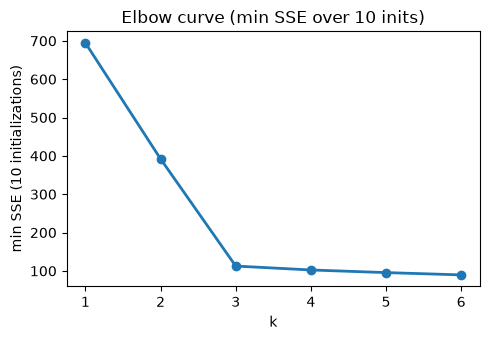

In [4]:
sbest = {}
for k in range(1, 7):
    sses = []
    for _ in range(10):
        c, lab, _ = kmeans(X, k)
        sses.append(sse(X, lab, c))
    sbest[k] = min(sses)
    print(f"k={k}: min SSE = {sbest[k]:8.1f}")

fig, ax = plt.subplots(figsize=(5, 3.5))
ks = list(sbest)
ax.plot(ks, [sbest[k] for k in ks], "o-", lw=2)
ax.set_xlabel("k")
ax.set_ylabel("min SSE (10 initializations)")
ax.set_title("Elbow curve (min SSE over 10 inits)")
ax.set_xticks(ks)
plt.tight_layout()
fig.savefig("/home/smhan/book-ml/kor/src/images/ch04_kmeans_elbow.svg")
print("SVG 저장: kor/src/images/ch04_kmeans_elbow.svg")
plt.show()

## 5. 초기화의 위험: 무작위 초기화 60회 돌려서 실패 사례 찾아보기

무작위로 서로 다른 3점을 초기 중심점으로 잡고 60번 돌렸을 때, 수렴한 SSE가 정답 구조(3개 덩어리 각각)보다 크게 나온 횟수를 센다. 본문의 실패 케이스처럼 "왼쪽 덩어리 안에 두 중심점이 몰리는" 초기화가 실제로 나오는지 확인한다.

In [5]:
def run_once(X, k, seed_init):
    rng = np.random.RandomState(seed_init)
    c0 = X[rng.choice(n, size=k, replace=False)]
    centroids = c0
    for _ in range(100):
        dist2 = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = dist2.argmin(axis=1)
        new_centroids = np.array(
            [X[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i]
             for i in range(k)])
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids
    return c0, centroids, labels

# 수렴한 SSE 분포 (60회)
results = []
for seed in range(60):
    c0, c, lab = run_once(X, 3, seed)
    results.append((sse(X, lab, c), seed, c0, c, lab))

sse_vals = sorted(r[0] for r in results)
failures = [r for r in results if r[0] > 1.5 * sse_vals[0]]
print(f"60회 중 SSE {sse_vals[0]:.1f} (정답 구조) 근처: {60 - len(failures)}회")
print(f"실패(>>정답): {len(failures)}회")
for s, seed, c0, c, lab in failures[:3]:
    sizes = [int((lab == i).sum()) for i in range(3)]
    print(f"  seed={seed}: SSE={s:.1f} (정답의 {s / sse_vals[0]:.1f}배)")
    print(f"    초기 중심점: {np.round(c0, 2).tolist()}  ->  수렴 클러스터 크기: {sizes}")

60회 중 SSE 112.7 (정답 구조) 근처: 38회
실패(>>정답): 22회
  seed=1: SSE=381.9 (정답의 3.4배)
    초기 중심점: [[0.92, 2.88], [7.46, 9.49], [6.96, 10.03]]  ->  수렴 클러스터 크기: [100, 27, 23]
  seed=2: SSE=392.4 (정답의 3.5배)
    초기 중심점: [[0.46, 2.07], [0.57, 1.91], [7.09, 2.14]]  ->  수렴 클러스터 크기: [31, 19, 100]
  seed=6: SSE=391.8 (정답의 3.5배)
    초기 중심점: [[-0.06, 2.25], [6.67, 2.25], [1.12, 1.41]]  ->  수렴 클러스터 크기: [31, 100, 19]


## 6. k-means++ 초기화 vs 단순 무작위 초기화 (각 20회)

D(x)²에 비례해 다음 중심점을 고르는 k-means++는 "같은 덩어리에 두 중심점이 몰리는" 상황을 구조적으로 막는다. 각 20회 돌려서 SSE 범위를 비교한다 — 본문의 표처럼 k-means++는 모두 정답 구조에, 단순 무작위는 1~2회 크게 이탈하는 모습을 확인한다 (이탈 횟수는 시드에 따라 다름).

단순 무작위 20회: SSE 112.7 ~ 529.6
k-means++ 20회:  SSE 112.7 ~ 383.3


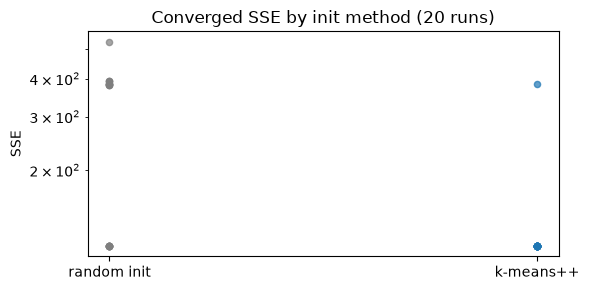

In [6]:
def kmeanspp_init(X, k, rng):
    centroids = [X[rng.randint(len(X))]]
    for _ in range(1, k):
        d2 = np.min(np.linalg.norm(X[:, None, :] - np.array(centroids)[None, :, :], axis=2), axis=1)
        probs = d2 ** 2 / (d2 ** 2).sum()
        centroids.append(X[rng.choice(len(X), p=probs)])
    return np.array(centroids)

def run_with_init(X, centroids, k, max_iters=100):
    for _ in range(max_iters):
        dist2 = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = dist2.argmin(axis=1)
        new_centroids = np.array(
            [X[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i]
             for i in range(k)])
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids
    return centroids, labels

random_sses, pp_sses = [], []
for seed in range(20):
    rng = np.random.RandomState(1000 + seed)
    c0 = X[rng.choice(n, size=3, replace=False)]
    c, lab = run_with_init(X, c0, k=3)
    random_sses.append(sse(X, lab, c))
for seed in range(20):
    rng = np.random.RandomState(2000 + seed)
    c0 = kmeanspp_init(X, 3, rng)
    c, lab = run_with_init(X, c0, k=3)
    pp_sses.append(sse(X, lab, c))

print(f"단순 무작위 20회: SSE {min(random_sses):.1f} ~ {max(random_sses):.1f}")
print(f"k-means++ 20회:  SSE {min(pp_sses):.1f} ~ {max(pp_sses):.1f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(np.repeat(0, 20), random_sses, c="tab:gray", alpha=0.7, s=20)
ax.scatter(np.repeat(1, 20), pp_sses, c="tab:blue", alpha=0.7, s=20)
ax.set_xticks([0, 1])
ax.set_xticklabels(["random init", "k-means++"])
ax.set_ylabel("SSE")
ax.set_title("Converged SSE by init method (20 runs)")
ax.set_yscale("log")
plt.tight_layout()
plt.show()